# Credit Card Fraud Detection — Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the distributions and relationships between transaction features and fraud.

We will analyze:
- Class distribution
- Transaction amounts
- Transaction time
- Feature distributions
- Correlations
- Differences between fraudulent and normal transactions

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("../data/processed/creditcard_clean.csv")

df.shape

(283726, 31)

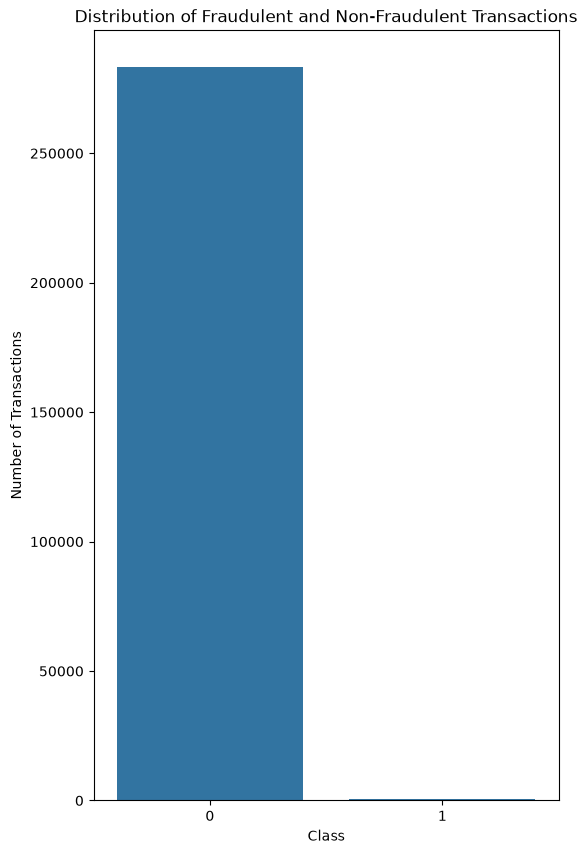

In [27]:
plt.figure(figsize=(6, 10))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Fraudulent and Non-Fraudulent Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

In [28]:
class_percentage = df["Class"].value_counts(normalize=True) * 100

print(class_percentage)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


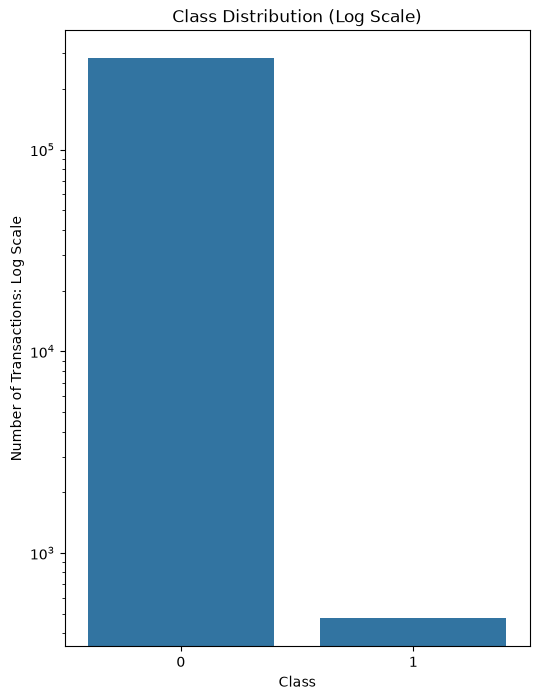

In [29]:
plt.figure(figsize=(6, 8))

sns.countplot(data=df, x="Class")

plt.yscale("log")

plt.title("Class Distribution (Log Scale)")
plt.xlabel("Class")
plt.ylabel("Number of Transactions: Log Scale")

plt.show()

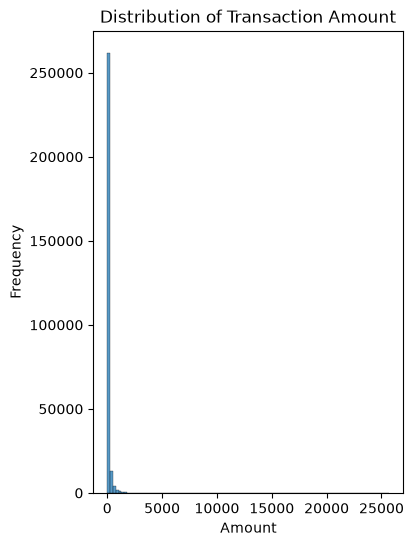

In [30]:
plt.figure(figsize=(4, 6))

sns.histplot(data=df, x="Amount", bins=100)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

In [31]:
(df["Amount"] == 0).sum()

np.int64(1808)

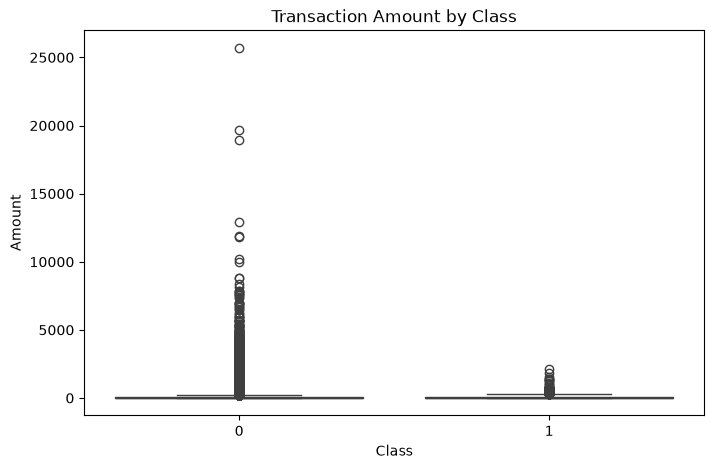

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Class", y="Amount")

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

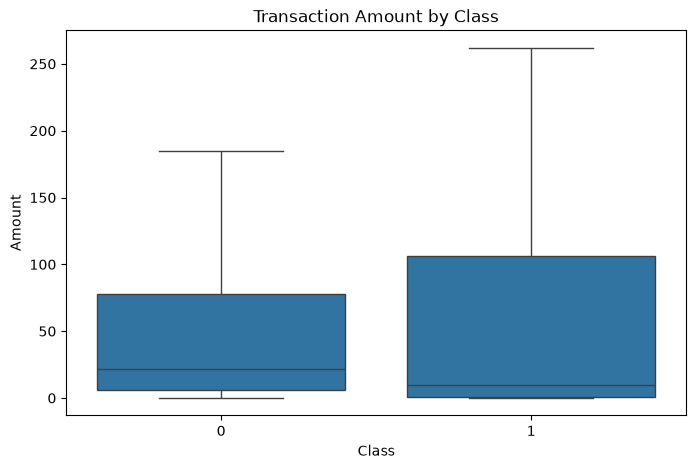

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Class", y="Amount", showfliers=False)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

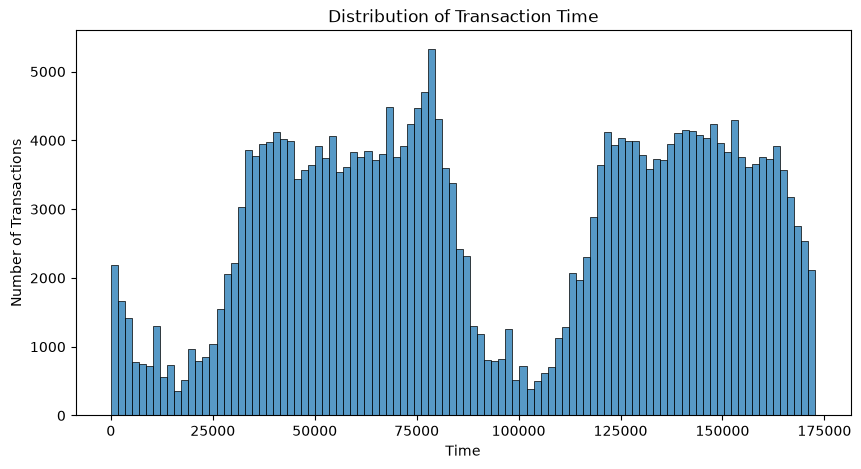

In [34]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="Time", bins=100)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

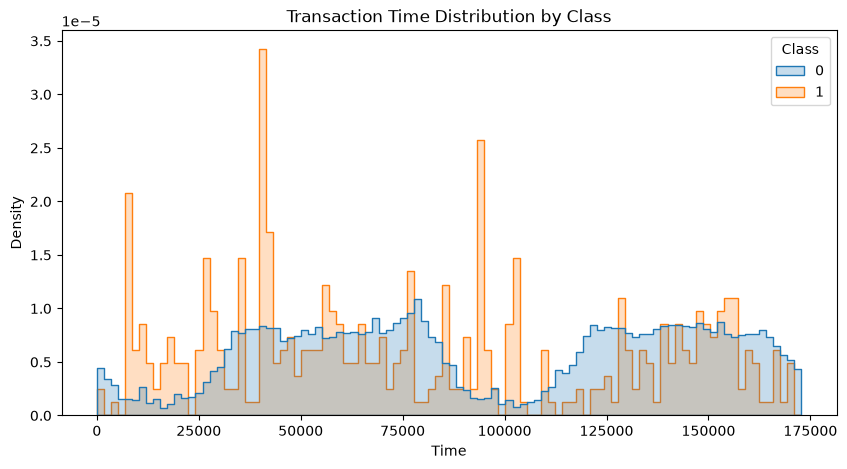

In [35]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time")
plt.ylabel("Density")

plt.show()

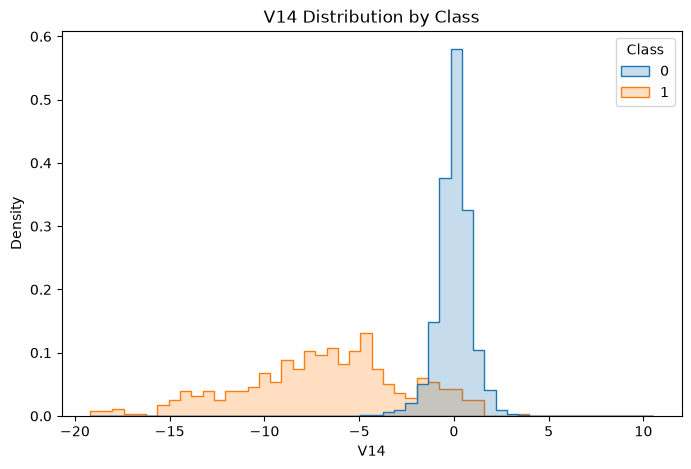

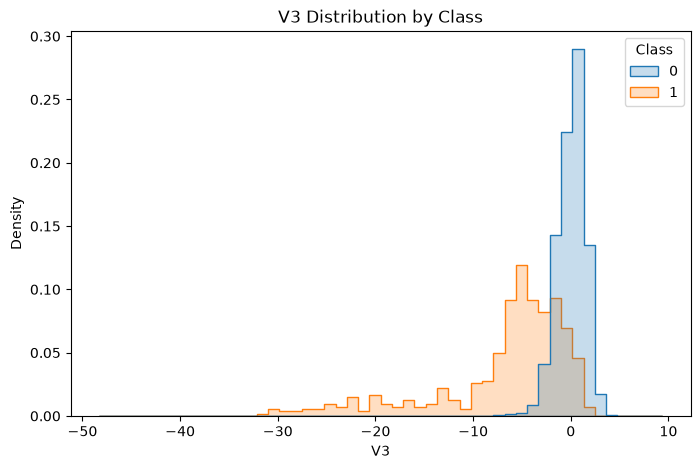

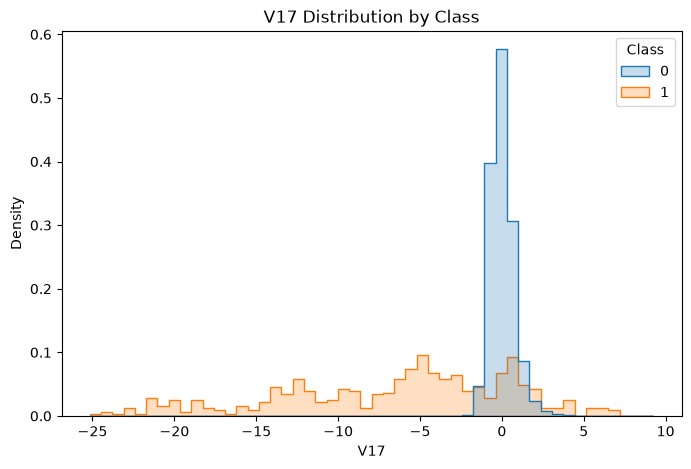

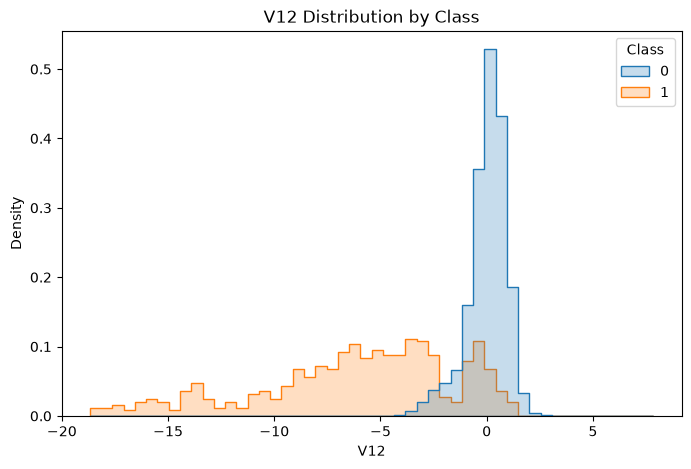

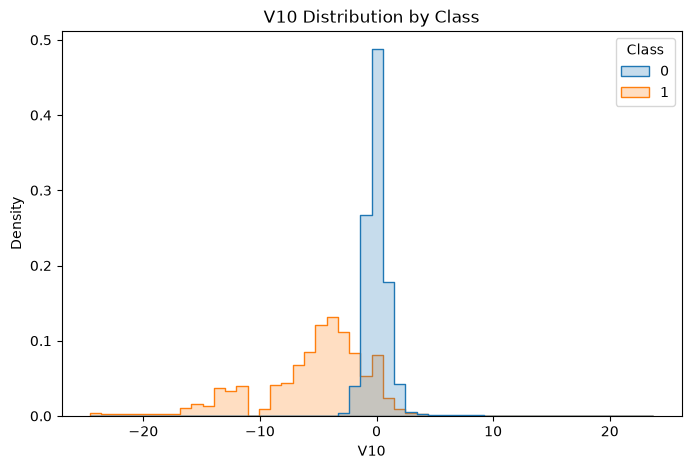

In [36]:
features_to_plot = ["V14", "V3", "V17", "V12", "V10"]
for feature in features_to_plot:
    
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=df,
        x=feature,
        hue="Class",
        bins=50,
        stat="density",
        common_norm=False,
        element="step"
    )
    
    plt.title(f"{feature} Distribution by Class")
    plt.xlabel(feature)
    plt.ylabel("Density")
    
    plt.show()

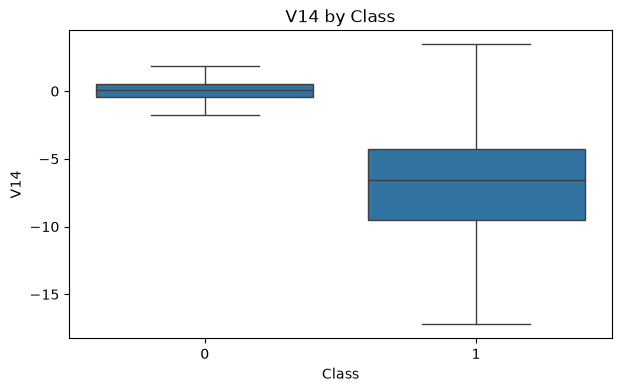

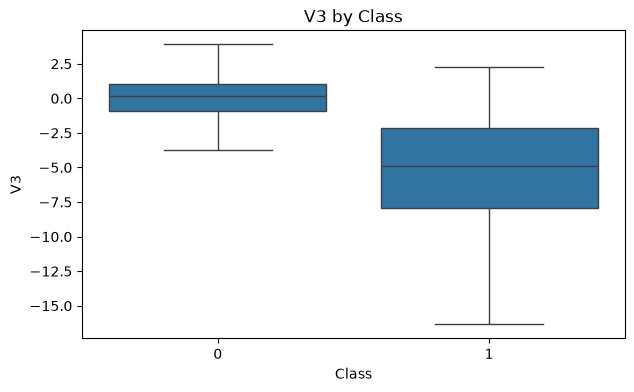

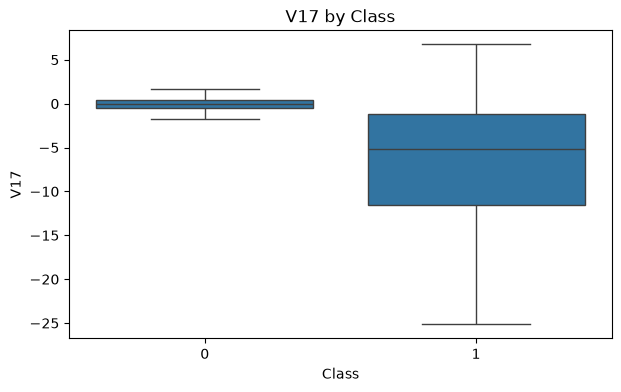

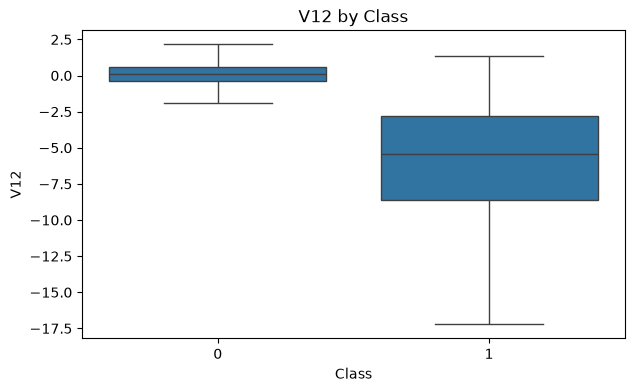

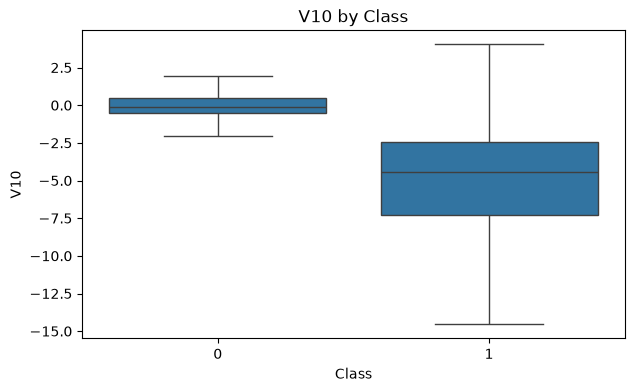

In [37]:
for feature in features_to_plot:
    
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(
        data=df,
        x="Class",
        y=feature,
        showfliers=False
    )
    
    plt.title(f"{feature} by Class")
    plt.xlabel("Class")
    plt.ylabel(feature)
    
    plt.show()

In [38]:
correlation_matrix = df.corr(numeric_only=True)

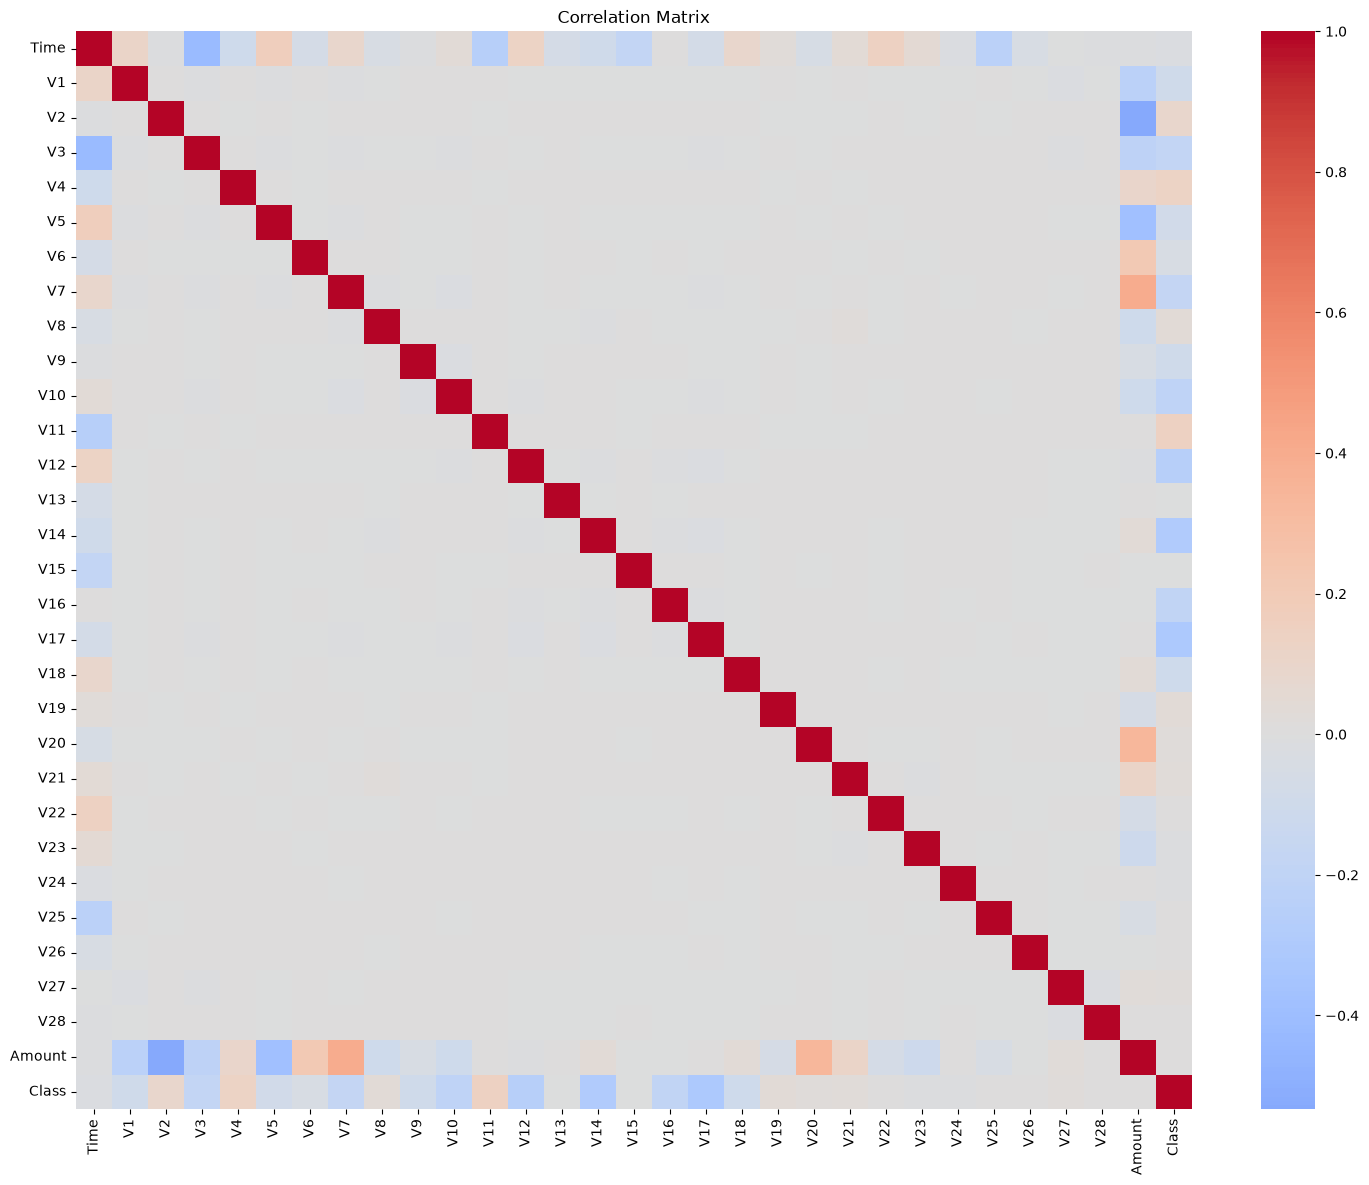

In [39]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [40]:
class_correlation = (
    df.corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values()
)

class_correlation

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Name: Class, dtype: float64

In [41]:
print("Most negative correlations:")
print(class_correlation.head(5))

print("\nMost positive correlations:")
print(class_correlation.tail(5))

Most negative correlations:
V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
Name: Class, dtype: float64

Most positive correlations:
V8     0.033068
V19    0.033631
V2     0.084624
V4     0.129326
V11    0.149067
Name: Class, dtype: float64


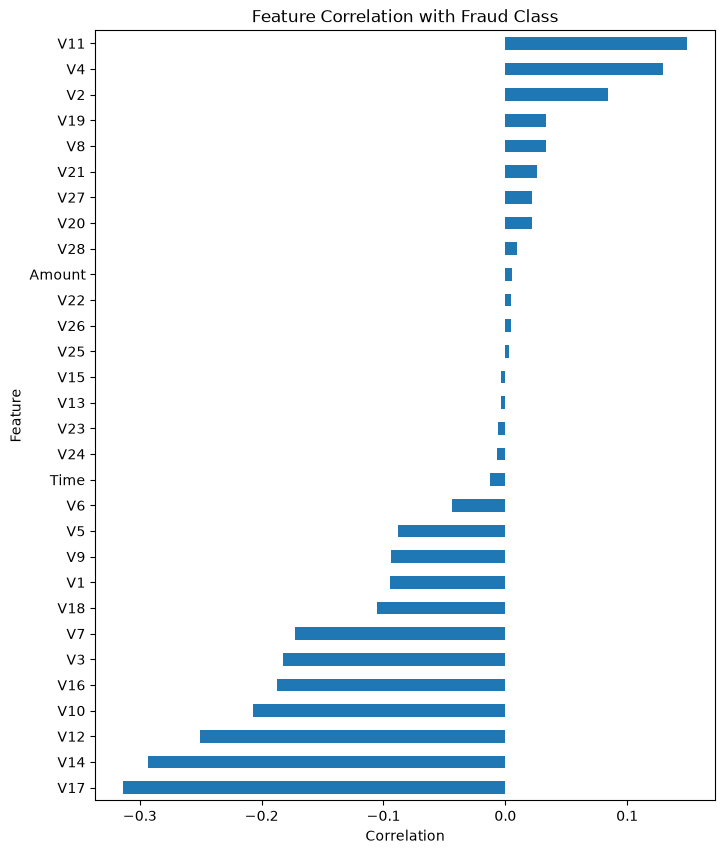

In [42]:
plt.figure(figsize=(8, 10))

class_correlation.plot(kind="barh")

plt.title("Feature Correlation with Fraud Class")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

# Key Insights

## 1. Strong Class Imbalance

The dataset is highly imbalanced. Fraudulent transactions represent only a very small proportion of all transactions.

This means that accuracy alone will not be sufficient to evaluate a fraud detection model.

## 2. Transaction Amount

The distribution of transaction amounts is highly skewed, with many relatively small transactions and a smaller number of large transactions.

The average transaction amount is higher for fraudulent transactions than for non-fraudulent transactions.

## 3. Anonymized Features

Several anonymized features show substantial differences between fraudulent and non-fraudulent transactions.

Features such as V14, V3, V17, V12 and V10 showed some of the largest differences in mean values.

## 4. Correlation with Fraud

V17, V14, V12, V10 and V16 show the strongest negative correlations with the target variable.

On the positive side, V11 and V4 show the strongest correlations with the fraud class.

However, correlation does not necessarily represent predictive importance or causality.

## 5. Time

The distribution of transaction time differs between fraudulent and non-fraudulent transactions, suggesting that transaction timing may contain useful information.

## 6. Machine Learning Implications

The exploratory analysis suggests that several features contain useful information for distinguishing fraudulent transactions.

However, the extreme class imbalance is the main challenge for the machine learning stage.

Therefore, model evaluation will focus on metrics such as precision, recall, F1-score and PR-AUC rather than accuracy alone.